In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("BTCUSDT15M.csv")
df['open_time'] = pd.to_datetime(df['open_time'])
df = df.set_index("open_time")

In [3]:
# calculate vwap with bands
import math
import pandas
from pandas import Series, DataFrame
from pandas_ta.overlap import hlc3
from pandas_ta.utils import get_offset, is_datetime_ordered, verify_series


def vwap_with_bands(
    high: Series, low: Series, close: Series, volume: Series, bands: list = [-1,1],
    anchor: str = None,
    offset: int = None, **kwargs
):
   
    # Validate
    high = verify_series(high)
    low = verify_series(low)
    close = verify_series(close)
    volume = verify_series(volume)
    anchor = anchor.upper() if anchor and isinstance(
        anchor, str) and len(anchor) >= 1 else "D"
    offset = get_offset(offset)

    typical_price = hlc3(high=high, low=low, close=close)
    if not is_datetime_ordered(volume):
        _s = "[!] VWAP volume series is not datetime ordered."
        print(f"{_s} Results may not be as expected.")
    if not is_datetime_ordered(typical_price):
        _s = "[!] VWAP price series is not datetime ordered."
        print(f"{_s} Results may not be as expected.")

    # Calculate vwap
    wp = typical_price * volume
    vwap = wp.groupby(wp.index.to_period(anchor)).cumsum()
    vwap /= volume.groupby(volume.index.to_period(anchor)).cumsum()

    # Calculate vwap stdev bands
    var = volume * (typical_price *typical_price)
    var_sum = var.groupby(var.index.to_period(anchor)).cumsum()
    volume_sum = volume.groupby(volume.index.to_period(anchor)).cumsum()
    stddev_vwap = abs(var_sum/volume_sum - vwap*vwap)
    std_volume_weighted =  stddev_vwap.apply(math.sqrt)
    
    # Build Dataframe
    df = pandas.DataFrame()
    df[f"VWAP_{anchor}"] = vwap
    for i in bands:
        df[f"{i}_VWAP_band"] = vwap + (i*std_volume_weighted)

    # Offset
    if offset != 0:
        vwap = vwap.shift(offset)

    # Fill
    if "fillna" in kwargs:
        vwap.fillna(kwargs["fillna"], inplace=True)
    if "fill_method" in kwargs:
        vwap.fillna(method=kwargs["fill_method"], inplace=True)

    # Name and Category
    vwap.name = f"VWAP_{anchor}_bands"
    vwap.category = "overlap"

    return df

In [4]:
# Calculate the VWAP with bands
vwap_with_bands = vwap_with_bands(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    bands=[-3,3],
    anchor="D"
)

##merge vwap with bands with og df
df = pd.merge(df, vwap_with_bands, left_index=True, right_index=True)

In [5]:
df["open_time"] = df.index

# strategy backtest

In [6]:
##find signals 
def find_signal(close, high, low, vwap,  upperband, lowerband):
    if (low < lowerband) & (close > lowerband) & (close < vwap):
        return 'buy'
    elif (high > upperband) & (close < upperband) & (close > vwap):
        return 'sell'

df['signal'] = np.vectorize(find_signal)(df['close'],df['high'], df['low'],df['VWAP_D'], df.iloc[:, 7], df.iloc[:, 6])

In [7]:
##creating backtest and position classes
class Position:
    def __init__(self, open_datetime, open_price, ordertype, volume, sl, tp):
        self.open_datetime = open_datetime
        self.open_price = open_price
        self.ordertype = ordertype
        self.volume = volume
        self.sl = sl
        self.tp = tp
        self.close_datetime = None
        self.close_price = None
        self.profit = None
        self.status = 'open'

    def close_position(self, close_datetime, close_price):
        self.close_datetime = close_datetime
        self.close_price = close_price
        self.profit = (self.close_price - self.open_price) * self.volume if self.ordertype == 'buy' \
            else (self.open_price - self.close_price) * self.volume
        self.status = 'close'

    def asdict(self):
        return {
            "open_datetime": self.open_datetime,
            "open_price": self.open_price,
            "order_type": self.ordertype,
            "volume": self.volume,
            "sl": self.sl,
            "tp": self.tp,
            "close_datetime": self.close_datetime,
            "close_price": self.close_price,
            "profit": self.profit,
            "status": self.status,
        }

class Strategy:
    def __init__(self, df, starting_balance, volume):
        self.startingbalance = starting_balance
        self.volume = volume
        self.positions = []
        self.data = df
        self.buy_pnl = 0  # Initialize buy profit and loss
        self.sell_pnl = 0  # Initialize sell profit and loss

    def get_positions_df(self):
        df = pd.DataFrame([position.asdict() for position in self.positions])
        df['pnl'] = df['profit'].cumsum() + self.startingbalance
        return df

    def add_position(self, position):
        self.positions.append(position)

    def trading_allowed(self):
        for pos in self.positions:
            if pos.status == 'open':
                return False
        return True

    def run(self):
        for i, data in self.data.iterrows():
            if data.signal == 'buy' and self.trading_allowed():
                sl = data.low
                tp = data.VWAP_D
                self.add_position(Position(data.open_time, data.close+(data.close*0.0005), data.signal, self.volume, sl, tp))
            elif data.signal == 'sell' and self.trading_allowed():
                sl = data.high
                tp = data.VWAP_D
                self.add_position(Position(data.open_time, data.close-(data.close*0.0005), data.signal, self.volume, sl, tp))

            for pos in self.positions:
                if pos.status == 'open':
                    # Check if VWAP_D has changed and update TP accordingly
                    if data.VWAP_D != pos.tp:
                        pos.tp = data.VWAP_D  # Update TP with the new 'VWAP_D' value
                        if (pos.ordertype == 'buy'):
                            if (pos.sl >= data.close):
                                pos.close_position(data.open_time, pos.sl)  # Close at stop loss price
                                self.buy_pnl += pos.profit  # Accumulate buy profit or loss
                            elif (pos.tp <= data.close):
                                pos.close_position(data.open_time, pos.tp)  # Close at take profit price
                                self.buy_pnl += pos.profit  # Accumulate buy profit or loss
                        elif (pos.ordertype == 'sell'):
                            if (pos.sl <= data.close):
                                pos.close_position(data.open_time, pos.sl)  # Close at stop loss price
                                self.sell_pnl += pos.profit  # Accumulate sell profit or loss
                            elif (pos.tp >= data.close):
                                pos.close_position(data.open_time, pos.tp)  # Close at take profit price
                                self.sell_pnl += pos.profit  # Accumulate sell profit or loss
 # Calculate total P&L by adding buy and sell P&L
        total_pnl = self.buy_pnl + self.sell_pnl
        print(f"Total P&L: {total_pnl}")
        return self.get_positions_df()

In [8]:
##backtesting strategy
vwap_strategy = Strategy(df,30000,1)
result = vwap_strategy.run()

Total P&L: -5652.7508074430625


result.to_csv("vwapbandsresult.csv", index = False)

<Axes: >

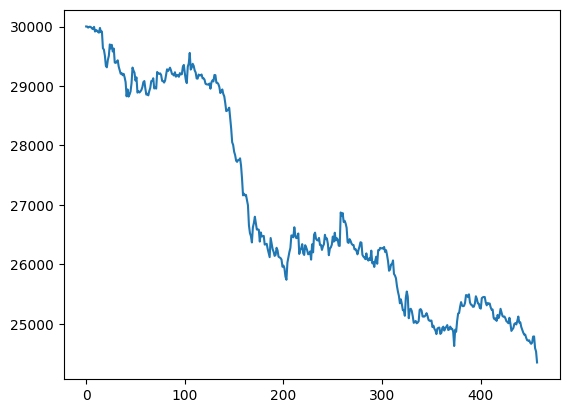

In [9]:
result.pnl.plot()